Starting loading to local disk...
File ready


Caricamento: 100%|██████████| 80000/80000 [01:27<00:00, 912.64it/s] 


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 Training phase...
Epoch 1/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 302s 300ms/step - accuracy: 0.7105 - auc: 0.7854 - loss: 0.9737 - recall: 0.7708 - val_accuracy: 0.7851 - val_auc: 0.8678 - val_loss: 0.5246 - val_recall: 0.7964 - learning_rate: 1.0000e-05
Epoch 2/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 180s 288ms/step - accuracy: 0.7799 - auc: 0.8666 - loss: 0.7549 - recall: 0.8444 - val_accuracy: 0.8014 - val_auc: 0.8888 - val_loss: 0.4791 - val_recall: 0.8039 - learning_rate: 1.0000e-05
Epoch 3/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 287ms/step - accuracy: 0.8028 - auc: 0.8919 - loss: 0.6720 - recall: 0.8704 - val_accuracy: 0.8155 - val_auc: 0.9003 - val_loss: 0.4542 - val_recall: 0.8177 - learning_rate: 1.0000e-05
Epoch 4/40
625/625 ━━━━━━━━━━━━━━━━━━━━ 180s 289ms/step - accuracy: 0.8195 - auc: 0.9081 - loss: 0.6176 - recall: 0.8840 - val_accuracy: 0.8216 - val_auc: 0.9065 - val_loss: 0.4399 - val_recall: 0.8140 - learning_rate: 1.0000e-05
Epoch 5/4

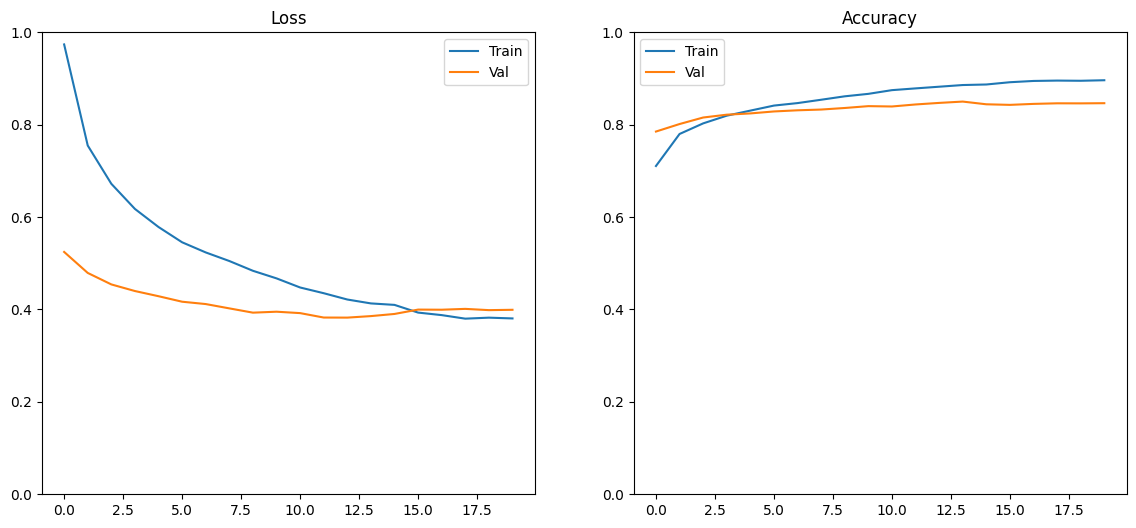


 Evaluation on the test set...
128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 76ms/step

--- Final report (Threshold: 0.5) ---
              precision    recall  f1-score   support

     Healthy       0.79      0.90      0.84     16391
       Tumor       0.88      0.75      0.81     16377

    accuracy                           0.83     32768
   macro avg       0.83      0.83      0.83     32768
weighted avg       0.83      0.83      0.83     32768



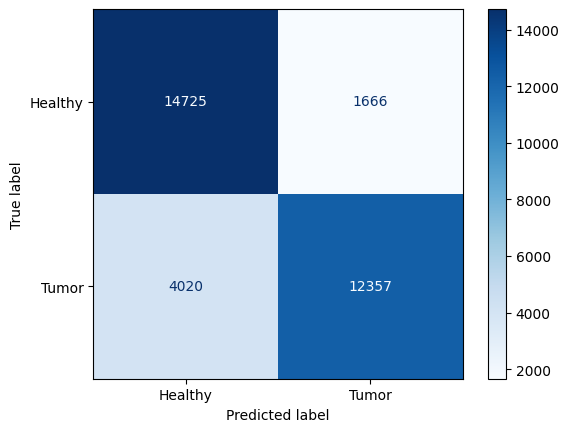

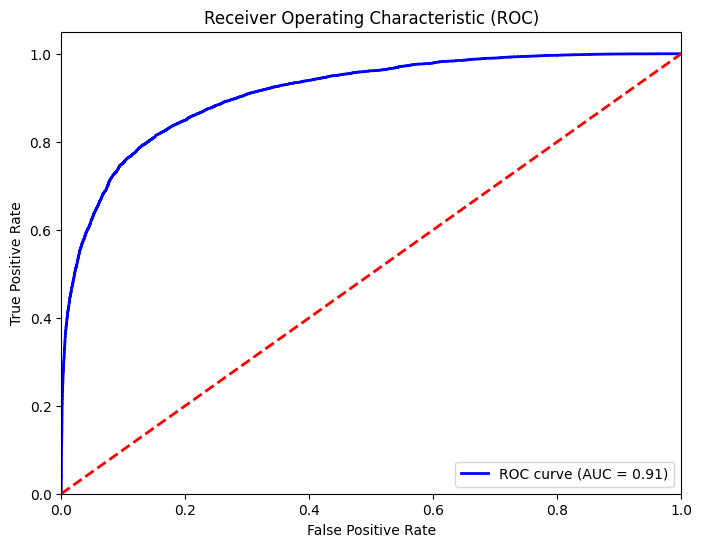

In [1]:
from google.colab import drive
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tqdm import tqdm

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("Starting loading to local disk...")
!rm -rf /content/*.h5
for f in ['train_x','train_y','valid_x','valid_y','test_x','test_y']:
    src = f"/content/drive/MyDrive/PCam/camelyonpatch_level_2_split_{f}.h5"
    if os.path.exists(src):
        !cp "$src" /content/
print("File ready")

# LOADING DATA
def load_to_ram_safe(x_path, y_path, num_samples=80000):
    with h5py.File(y_path, 'r') as fy:
        y_all = fy['y'][:].reshape(-1)
        idx_0 = np.where(y_all == 0)[0]
        idx_1 = np.where(y_all == 1)[0]
        n = num_samples // 2
        selected_indices = np.concatenate([np.random.choice(idx_0, n, replace=False),
                                            np.random.choice(idx_1, n, replace=False)])
        np.random.shuffle(selected_indices)
        y_final = y_all[selected_indices].reshape(-1, 1)

    x_final = np.empty((num_samples, 96, 96, 3), dtype='uint8')
    with h5py.File(x_path, 'r') as fx:
        ds = fx['x']
        for i, idx in enumerate(tqdm(selected_indices, desc="Caricamento")):
            x_final[i] = ds[idx]
    return x_final, y_final

X_train, Y_train = load_to_ram_safe('/content/camelyonpatch_level_2_split_train_x.h5',
                                    '/content/camelyonpatch_level_2_split_train_y.h5', 80000)
with h5py.File('/content/camelyonpatch_level_2_split_valid_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_valid_y.h5','r') as fy:
    X_val, Y_val = fx['x'][:8000], fy['y'][:8000].reshape(-1,1)

# MODEL ARCHITECTURE
tf.keras.mixed_precision.set_global_policy('mixed_float16')

def build_advanced_model():
    inputs = layers.Input(shape=(96, 96, 3))

    # Data Augmentation Fundamental for histopathology
    x = layers.CenterCrop(64, 64)(inputs)
    x = layers.RandomFlip("horizontal_and_vertical")(x)
    x = layers.RandomRotation(0.5)(x)
    x = layers.RandomBrightness(0.15)(x)
    x = layers.RandomContrast(0.15)(x)

    x = tf.keras.applications.densenet.preprocess_input(x)

    base_model = tf.keras.applications.DenseNet121(
        weights='imagenet', include_top=False, input_shape=(64, 64, 3)
    )
    base_model.trainable = True

    x = base_model(x)

    # Using the SpatialDropout
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    return models.Model(inputs, outputs)

model = build_advanced_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)

# TRAINING PHASE
class_weights = {0: 1.0, 1: 2.0}

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train)).shuffle(2000).batch(128).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val)).batch(128).prefetch(tf.data.AUTOTUNE)

callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1)
]

print("\n Training phase...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_list
)

# Saving the model
model.save('/content/drive/MyDrive/PreTrained_Base_model.keras')
print("Model saved successfully to Google Drive")

plt.figure(figsize=(14,6))
plt.subplot(1,2,1); plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val'); plt.title("Loss"); plt.ylim(0, 1.0); plt.legend()
plt.subplot(1,2,2); plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val'); plt.title("Accuracy"); plt.ylim(0, 1.0); plt.legend()
plt.show()

# FINAL TEST SET EVALUATION
print("\n Evaluation on the test set...")
with h5py.File('/content/camelyonpatch_level_2_split_test_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_test_y.h5','r') as fy:
    X_test, Y_test = fx['x'][:], fy['y'][:].reshape(-1,1)

y_pred_prob = model.predict(X_test, batch_size=256)

threshold = 0.5
y_pred_class = (y_pred_prob > threshold).astype(int)

print(f"\n--- Final report (Threshold: {threshold}) ---")
print(classification_report(Y_test, y_pred_class, target_names=["Healthy","Tumor"]))

cm = confusion_matrix(Y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Tumor"])
disp.plot(cmap='Blues')
plt.show()

# ROC Curve plotting
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color="blue", lw=2, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()